# Merge WISeREP Meta Tables

# Input

## Library

In [1]:
# Python Library
import os
import glob
import sys
import numpy as np
import shutil
import time
start_time = time.time()

from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from astropy.table import vstack
from astropy.table import hstack
import warnings
warnings.filterwarnings("ignore")

# Plot presetting
import matplotlib.pyplot as plt
import matplotlib as mpl

# Jupyter Setting
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

## Function

In [2]:
def read_and_normalize_table(path, column_type_overrides=None):
    tbl = Table.read(path)
    if column_type_overrides:
        for colname, dtype in column_type_overrides.items():
            if colname in tbl.colnames:
                try:
                    tbl[colname] = tbl[colname].astype(dtype)
                except Exception as e:
                    print(f"[Warning] Failed to cast column {colname} in {path}: {e}")
    tbl['original_table_path'] = path
    return tbl

# 예시: 강제 타입 지정
column_type_overrides = {
	"IAU name": "str",
	"Spec. quality": "str",
	"Grism": "str",
	"Grating": "str",
	"End prop. period": "str",
	"Aperture (slit)": "str",
	"Reducer/s": "str",
	"Fits file": "str",
	"HA": "str",
	"Extinction-Corrected": "str",
	"Flux Calibrated": "str",
	"Flux Calibrated By": "str",
	"Dichroic": "str",
	"Contrib": "str",
	"Publish": "str",
    "Remarks": "str",  # 어차피 제거할 예정이라도 에러 방지
}

## Path & Useful Functions

In [3]:
import sys
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *

In [4]:
logtxt = ""

## Non-variable parameters

In [5]:
MIN_7DT_WAVELENGTH = 4000 - 125
MAX_7DT_WAVELENGTH = 8875 + 125

# Data

- Collect

In [6]:
selected_meta_tables = sorted(glob.glob(os.path.join(SPECTRA_WISEREP_DATA, '*', 'selected_spectra_meta_table.csv')))
print(f"Number of selected meta tables: {len(selected_meta_tables)}")
for selected_meta_table in selected_meta_tables:
    print(selected_meta_table)

logtxt += f"Number of selected meta tables: {len(selected_meta_tables)}\n"
for selected_meta_table in selected_meta_tables:
    logtxt += f"\t{selected_meta_table}\n"
logtxt += "\n"

Number of selected meta tables: 10
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/AGN/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/CV/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/FBOT/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/FRB/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/LBV/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/LRN/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Mdwarf/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Nova/selected_spectra_meta_table.csv
/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other/selected_s

- Merge

In [7]:
metatbl = vstack([read_and_normalize_table(table, column_type_overrides) for table in selected_meta_tables])
metatbl['broad_type'] = metatbl['Obj. Type']
metatbl['data_from'] = 'WISeREP'

types, types_counts = np.unique(metatbl['Obj. Type'], return_counts=True)
summarytbl = Table([types, types_counts], names=['Type', 'Count'])

print(f"Number of rows: {len(metatbl)}")
print(f"Number of columns: {len(metatbl.colnames)}")
print(f"Unique Type Count: {len(types)}")

logtxt += f"Number of rows: {len(metatbl)}\n"
logtxt += f"Number of columns: {len(metatbl.colnames)}\n"
logtxt += f"Unique Type Count: {len(types)}\n"
for typ in types:
    logtxt += f"\t{typ}: {types_counts[list(types).index(typ)]}\n"
logtxt += "\n"

summarytbl

Number of rows: 1240
Number of columns: 66
Unique Type Count: 10


Type,Count
str7,int64
AGN,160
CV,331
FBOT,8
FRB,5
LBV,38
LRN,29
M dwarf,15
Nova,40
Other,242


In [8]:
len(np.unique(metatbl['uid'])) == len(metatbl)

False

# Analyze

- Bar Chart

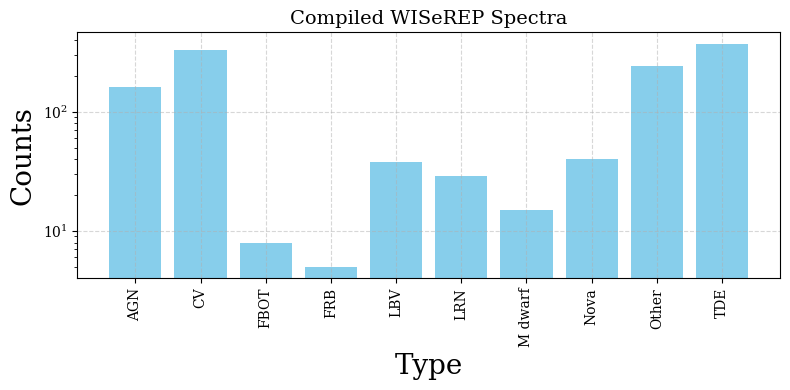

In [9]:
figure_filename = os.path.join(SPECTRA_WISEREP_DATA, "Compiled_WISeREP_spectra_bar.png")

# 바 그래프 시각화
plt.figure(figsize=(8, 4))
plt.bar(types, types_counts, color='skyblue')
plt.xticks(rotation=90, ha='center')  # 글자가 겹치지 않도록 회전
plt.ylabel("Counts")
plt.xlabel("Type")
plt.yscale('log')
plt.grid('both', ls='--', alpha=0.5, zorder=0)
plt.title("Compiled WISeREP Spectra")
plt.tight_layout()
plt.savefig(figure_filename)
plt.show()

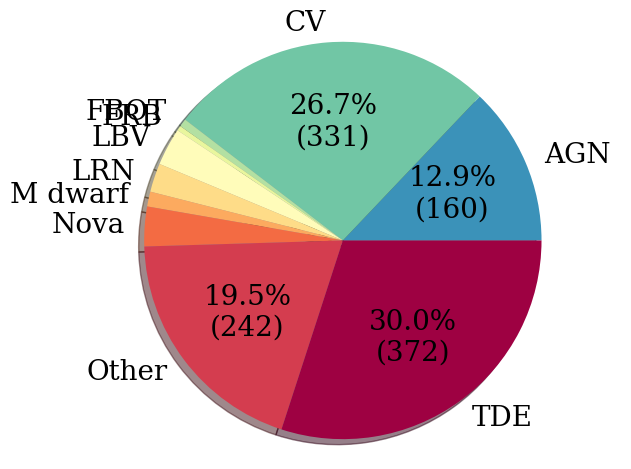

In [10]:
figure2_filename = os.path.join(SPECTRA_WISEREP_DATA, "Compiled_WISeREP_spectra_pie.png")

sizes = [len(metatbl[metatbl['broad_type']==typ]) for typ in types]
colors = makeSpecColors(len(types))
# 사용자 정의 함수로 퍼센티지와 숫자 표시
def make_autopct(values, fontsize=20, threshold=5):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        # 1000 이상의 숫자는 K로 표시
        val_str = f"{val/1000:.1f}K" if val >= 1000 else str(val)
        return '{p:.1f}%\n({v})'.format(p=pct, v=val_str) if pct >= threshold else ''
    return my_autopct

# 파이 차트 수정
plt.pie(sizes, labels=types, autopct=make_autopct(sizes, fontsize=20, threshold=5), 
        colors=colors[::-1], shadow=True, textprops={'fontsize': 20})
_ = plt.axis('equal')
plt.tight_layout()
plt.savefig(figure2_filename)
plt.show()

# Fin

In [11]:
summary_file_path = os.path.join(SPECTRA_WISEREP_DATA, "type_summary.csv")
summarytbl.write(summary_file_path, format="csv", overwrite=True)

logtxt += f"Summary table saved to {summary_file_path}\n"

In [12]:
merged_table_path = os.path.join(SPECTRA_WISEREP_DATA, "merged_spectra_meta_table.csv")
metatbl.write(merged_table_path, format="csv", overwrite=True)

logtxt += f"Merged table saved to {merged_table_path}\n"

In [13]:
delt = time.time() - start_time
logtxt += f"Time Elapsed: {delt:.1f} seconds\n"
logtxt += f"END\n\n\n"

logtxt_path = os.path.join(SPECTRA_WISEREP_DATA, 'log.txt')

with open(logtxt_path, 'w') as f:
	f.write(logtxt)

print(logtxt)

Number of selected meta tables: 10
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/AGN/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/CV/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/FBOT/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/FRB/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/LBV/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/LRN/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Mdwarf/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Nova/selected_spectra_meta_table.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other/s